In [1]:
import sys
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt

ox.__version__

'2.0.5'

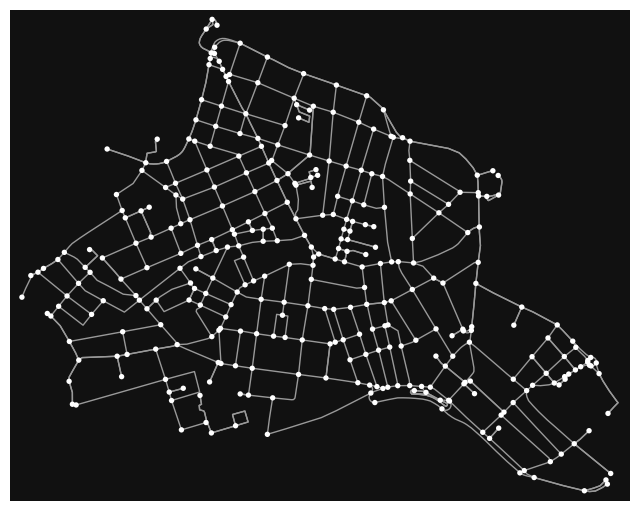

In [2]:
# download/model a street network for some city then visualize it
G = ox.graph.graph_from_place("Sliema, Malta", network_type="bike")
fig, ax = ox.plot.plot_graph(G)

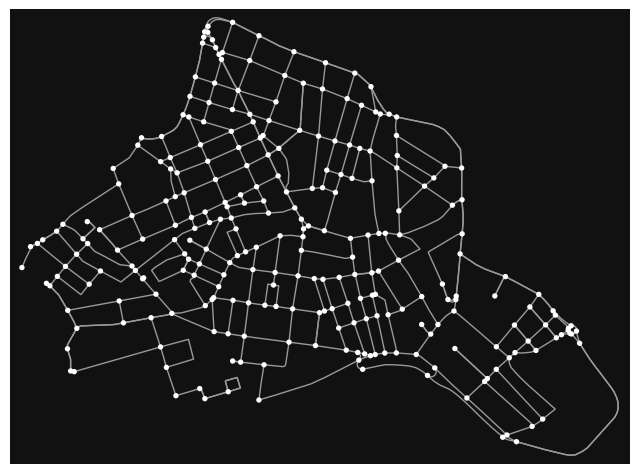

In [3]:
# download/model a street network for some city then visualize it
G = ox.graph.graph_from_place("Sliema, Malta", network_type="drive")
fig, ax = ox.plot.plot_graph(G)

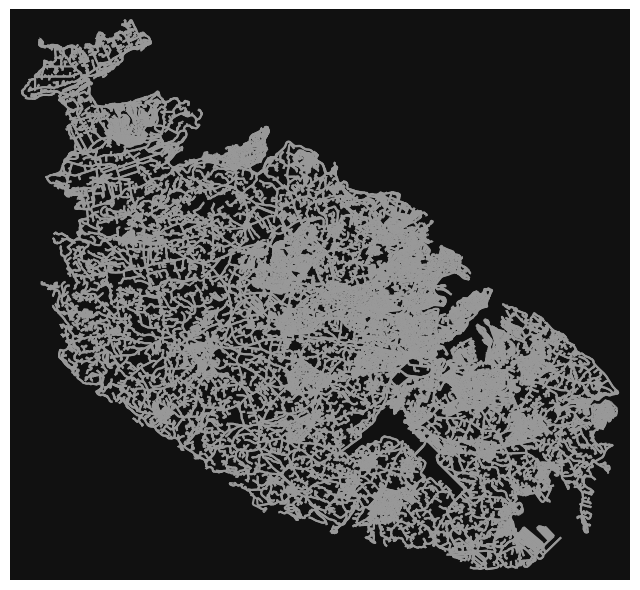

In [22]:
# download/model a street network for some city then visualize it
G = ox.graph.graph_from_place("Malta", network_type="bike")
fig, ax = ox.plot.plot_graph(G, node_size=0, edge_linewidth=1.5)

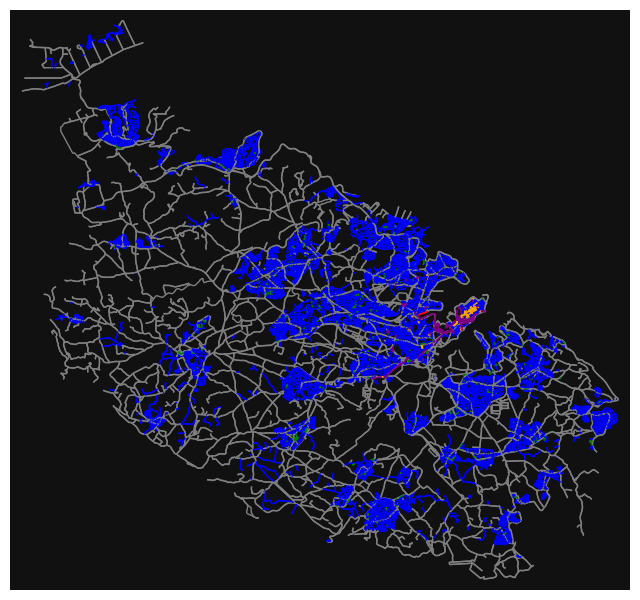

In [49]:
cycleways = '["cycleway"~"lane|track|share_busway|shared_lane"]' # cycleway = infrastructure type (physical/painted features)
highways = '["highway"~"residential|living_street|pedestrian|footway|cycleway"]'

bicycles = '["bicycle"!~"no"]' # bicycle = legal access (permission/prohibition)
access = '["access"!~"private"]'

cf = f'{highways}{bicycles}{access}'

G_drive = ox.graph.graph_from_place("Malta", network_type="drive")
G_cycle = ox.graph.graph_from_place("Malta", custom_filter=cf)

G = nx.compose(G_drive,G_cycle)
    
highway_color_map = {
    "residential": "blue",
    "living_street": "green",
    "pedestrian": "orange",
    "footway": "purple",
    "cycleway": "red"
}

# Get the color for each edge based on its 'highway' attribute
edge_colors = []
for u, v, k, data in G.edges(keys=True, data=True):
    highway = data.get("highway")
    # Some edges may have a list of highway types; handle that
    if isinstance(highway, list):
        highway = highway[0]
    color = highway_color_map.get(highway, "gray")  # default to gray if not found
    edge_colors.append(color)

fig, ax = ox.plot_graph(G, node_size=0, edge_color=edge_colors)

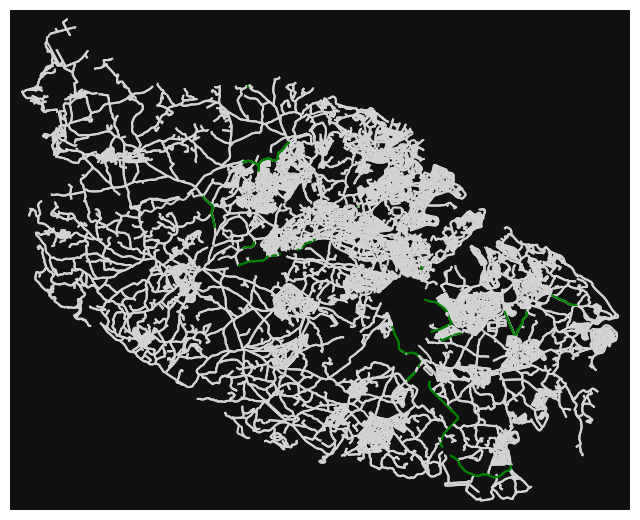

In [47]:
# download driving+cycling network to include cycleways
G = ox.graph_from_place(
    "Malta",
    custom_filter='["highway"~"cycleway|path|residential|primary|secondary|tertiary|unclassified"]'
)

# find protected/dedicated cycleways
protected_edges = [
    (u, v, k, data) 
    for u, v, k, data in G.edges(keys=True, data=True)
    if data.get("highway") == "cycleway"
       or data.get("cycleway") == "track"
]

# if you want only painted lanes
lane_edges = [
    (u, v, k, data) 
    for u, v, k, data in G.edges(keys=True, data=True)
    if data.get("cycleway") == "lane"
]

# Set edge colors: green for highway=cycleway, blue for cycleway=track, else lightgray
ec = [
    "green" if d.get("highway") == "cycleway" 
    else "blue" if d.get("cycleway") == "track" 
    else "lightgray"
    for u, v, k, d in G.edges(keys=True, data=True)
 ]

fig, ax = ox.plot_graph(G, node_size=0, edge_color=ec, edge_linewidth=1.5)

# Topology


In [5]:
"""raster_path = "../Data/ebk1km1.tif"
G = ox.elevation.add_node_elevations_raster(G, raster_path, cpus=1)
G = ox.elevation.add_edge_grades(G, add_absolute=True)"""

'raster_path = "../Data/ebk1km1.tif"\nG = ox.elevation.add_node_elevations_raster(G, raster_path, cpus=1)\nG = ox.elevation.add_edge_grades(G, add_absolute=True)'

# Basic street network stats

In [6]:
# what sized area does our network cover in square meters?
G_proj = ox.projection.project_graph(G)
nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
graph_area_m = nodes_proj.union_all().convex_hull.area
graph_area_m

1174061.3575504385

In [7]:
# show some basic stats about the network
ox.stats.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)

{'n': 265,
 'm': 495,
 'k_avg': 3.7358490566037736,
 'edge_length_total': 33378.793886743326,
 'edge_length_avg': 67.43190684190571,
 'streets_per_node_avg': 3.2037735849056603,
 'streets_per_node_counts': {0: 0, 1: 7, 2: 2, 3: 188, 4: 67, 5: 0, 6: 1},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.026415094339622643,
  2: 0.007547169811320755,
  3: 0.7094339622641509,
  4: 0.2528301886792453,
  5: 0.0,
  6: 0.0037735849056603774},
 'intersection_count': 258,
 'street_length_total': 28102.377726266095,
 'street_segment_count': 415,
 'street_length_avg': 67.71657283437614,
 'circuity_avg': 1.0457444960572306,
 'self_loop_proportion': 0.0024096385542168677,
 'clean_intersection_count': 194,
 'node_density_km': 225.71222389338834,
 'intersection_density_km': 219.75001420563845,
 'edge_density_km': 28430.195468135364,
 'street_density_km': 23936.03838976431,
 'clean_intersection_density_km': 165.2383827747824}

# Visualize street centrality

In [8]:
# convert graph to line graph so edges become nodes and vice versa
edge_centrality = nx.closeness_centrality(nx.line_graph(G))
nx.set_edge_attributes(G, edge_centrality, "edge_centrality")

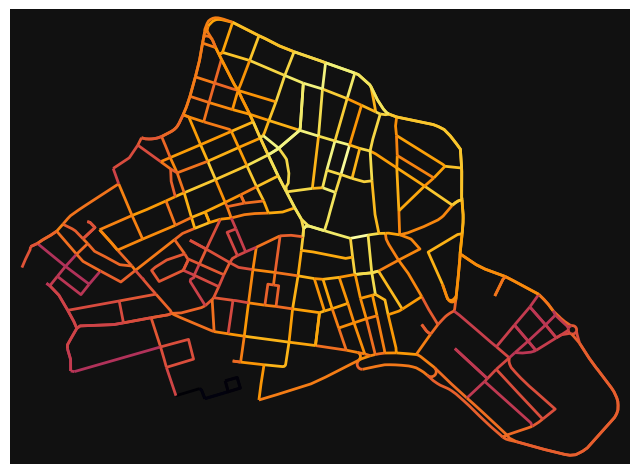

In [9]:
# color edges in original graph with closeness centralities from line graph
ec = ox.plot.get_edge_colors_by_attr(G, "edge_centrality", cmap="inferno")
fig, ax = ox.plot.plot_graph(G, edge_color=ec, edge_linewidth=2, node_size=0)

# Routing

In [10]:
# impute missing edge speeds and calculate edge travel times with the speed module
G = ox.routing.add_edge_speeds(G)
G = ox.routing.add_edge_travel_times(G)

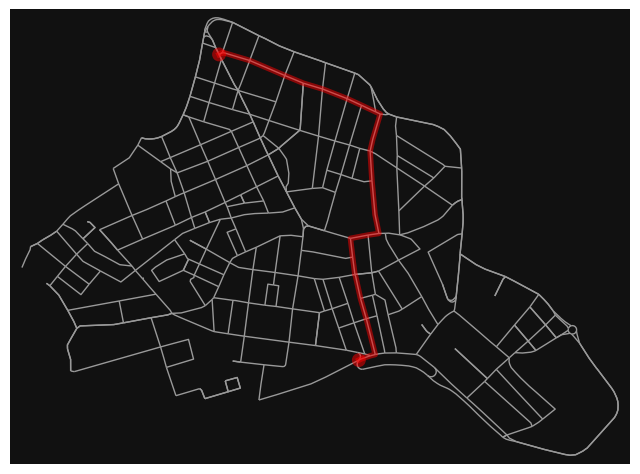

In [11]:
# get the nearest network nodes to two lat/lng points with the distance module
orig = ox.distance.nearest_nodes(G, X=35.893385, Y=14.477465)
dest = ox.distance.nearest_nodes(G, X=35.890245, Y=14.479616)

orig = next(iter(G))
dest = list(G)[-1]

# find the shortest path between nodes, minimizing travel time, then plot it
route = ox.routing.shortest_path(G, orig, dest, weight="travel_time")
fig, ax = ox.plot.plot_graph_route(G, route, node_size=0)

In [12]:
# how long is our route in meters?
edge_lengths = ox.routing.route_to_gdf(G, route)["length"]
round(sum(edge_lengths))

1295

In [13]:
# how far is it between these two nodes as the crow flies?
# use OSMnx's vectorized great-circle distance (haversine) function
orig_x = G.nodes[orig]["x"]
orig_y = G.nodes[orig]["y"]
dest_x = G.nodes[dest]["x"]
dest_y = G.nodes[dest]["y"]
round(ox.distance.great_circle(orig_y, orig_x, dest_y, dest_x))

946